# 贷款审批预测 — 探索性数据分析（EDA）

**目标**：理解数据分布、缺失值情况、特征与标签的关联性，为后续预处理和特征工程提供依据。

**数据集**：Kaggle Loan Prediction Problem Dataset  
**标签**：`Loan_Status`（Y = 贷款批准，N = 贷款拒绝）

---

## 目录

1. [环境与路径配置](#1)
2. [数据加载与基本信息](#2)
3. [缺失值分析](#3)
4. [标签分布（类别不均衡）](#4)
5. [数值特征分布与偏度](#5)
6. [类别特征与标签关联](#6)
7. [业务派生特征预览](#7)
8. [相关性热力图](#8)
9. [EDA 结论与数据处理建议](#9)


## 1. 环境与路径配置 <a id='1'></a>

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from matplotlib import font_manager

# ── 绘图风格 ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
pd.set_option('display.max_columns', 30)

# ============ 配置中文字体（放在 style.use 之后） ============
matplotlib.rcParams['axes.unicode_minus'] = False

candidates = [
    'PingFang SC',      # macOS 优先
    'Heiti SC',
    'STHeiti',
    'Arial Unicode MS',
    'Noto Sans CJK SC',
    'SimHei',
    'WenQuanYi Zen Hei',
    'DejaVu Sans'
]

installed = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in candidates if f in installed), 'DejaVu Sans')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font]
print('当前字体:', plt.rcParams['font.sans-serif'])

# ── 路径（兼容从 notebooks/ 或项目根目录运行）──────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
EDA_FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures' / 'eda'
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('train.csv 存在:', (RAW_DIR / 'train.csv').exists())
print('test.csv  存在:', (RAW_DIR / 'test.csv').exists())


当前字体: ['STHeiti']
PROJECT_ROOT: /Users/aaaa/Documents/GitHub/loan-approval-ml
train.csv 存在: True
test.csv  存在: True


## 2. 数据加载与基本信息 <a id='2'></a>

In [2]:
train = pd.read_csv(RAW_DIR / 'train.csv')
test  = pd.read_csv(RAW_DIR / 'test.csv')
print(f'训练集 shape: {train.shape}  测试集 shape: {test.shape}')
train.head()

训练集 shape: (614, 13)  测试集 shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
train.dtypes.to_frame('dtype').T

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
dtype,object,object,object,object,object,object,int64,float64,float64,float64,float64,object,object


In [4]:
# 数值列统计摘要
train.describe().round(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,600.00,564.00
mean,5403.46,1621.25,146.41,342.00,0.84
std,6109.04,2926.25,85.59,65.12,0.36
min,150.00,0.00,9.00,12.00,0.00
25%,2877.50,0.00,100.00,360.00,1.00
50%,3812.50,1188.50,128.00,360.00,1.00
75%,5795.00,2297.25,168.00,360.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00


## 3. 缺失值分析 <a id='3'></a>

缺失值将在 `preprocess.py` 中统一处理：**分类列→众数，数值列→中位数**。

                  缺失数量  缺失比例(%)
Credit_History      50     8.14
Self_Employed       32     5.21
LoanAmount          22     3.58
Dependents          15     2.44
Loan_Amount_Term    14     2.28
Gender              13     2.12
Married              3     0.49


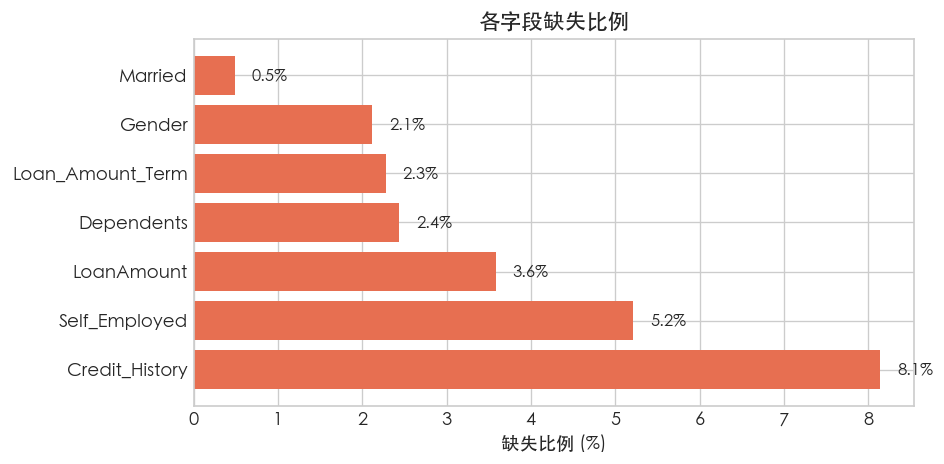

In [5]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': (missing / len(train) * 100).round(2)
})
print(missing_df)

# 可视化
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df['缺失比例(%)'], color='#E76F51')
ax.set_xlabel('缺失比例 (%)')
ax.set_title('各字段缺失比例')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', fontsize=10)
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'missing_values.png', dpi=150)
plt.show()

## 4. 标签分布（类别不均衡） <a id='4'></a>

正类（Y=批准）占 **68.7%**，负类（N=拒绝）占 **31.3%**，比约 2.2:1。

**处理策略**：三种模型均设置 `class_weight='balanced'`（LR/RF）或 `scale_pos_weight`（XGBoost）。

              数量  占比(%)
Loan_Status            
Y            422  68.73
N            192  31.27


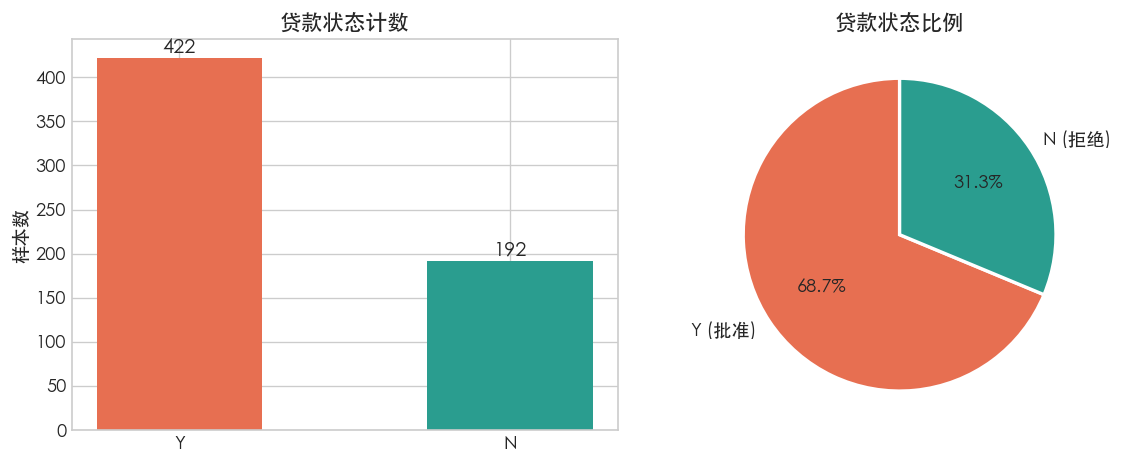

In [6]:
counts = train['Loan_Status'].value_counts()
ratios = train['Loan_Status'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'数量': counts, '占比(%)': ratios}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 条形图
colors = ['#E76F51', '#2A9D8F']
axes[0].bar(counts.index, counts.values, color=colors, width=0.5)
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('贷款状态计数')
axes[0].set_ylabel('样本数')

# 饼图
axes[1].pie(counts.values, labels=['Y (批准)', 'N (拒绝)'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('贷款状态比例')

plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'label_distribution.png', dpi=150)
plt.show()

## 5. 数值特征分布与偏度 <a id='5'></a>

收入和贷款额呈极端右偏分布，需要 **log1p 变换**（在 `features.py` 中处理）。

                     偏度  需要变换
ApplicantIncome    6.54  True
CoapplicantIncome  7.49  True
LoanAmount         2.68  True
Loan_Amount_Term  -2.36  True


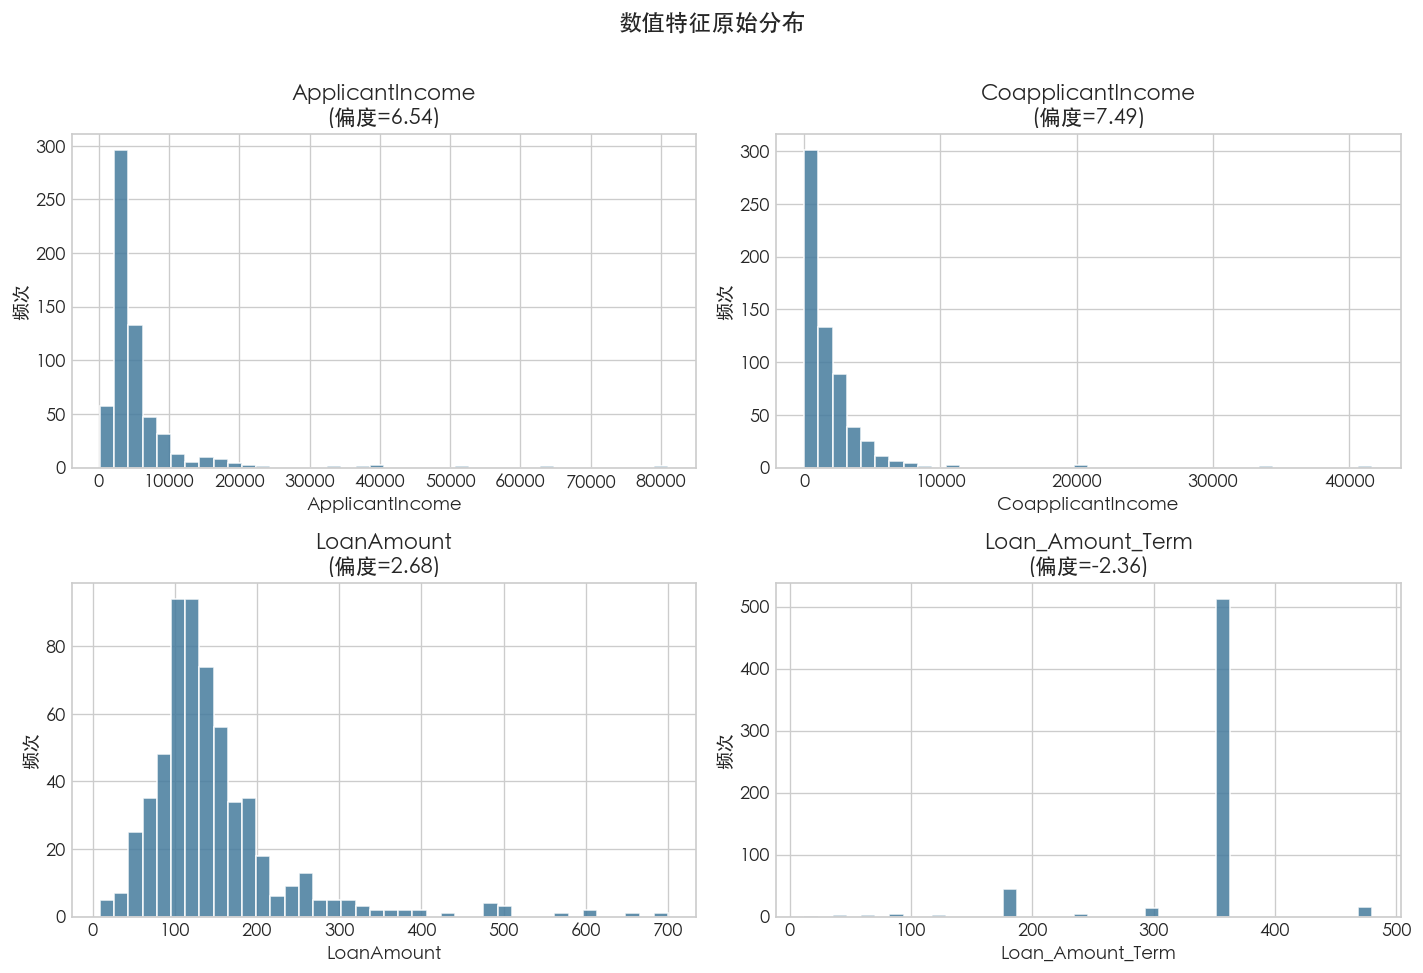

In [7]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# 偏度统计
skew_df = train[num_cols].skew().to_frame('偏度').round(2)
skew_df['需要变换'] = skew_df['偏度'].abs() > 1
print(skew_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(train[col].dropna(), bins=40, color='#457B9D', alpha=0.85, edgecolor='white')
    ax.set_title(f'{col}\n(偏度={train[col].skew():.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('频次')
plt.suptitle('数值特征原始分布', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'numeric_histograms.png', dpi=150)
plt.show()

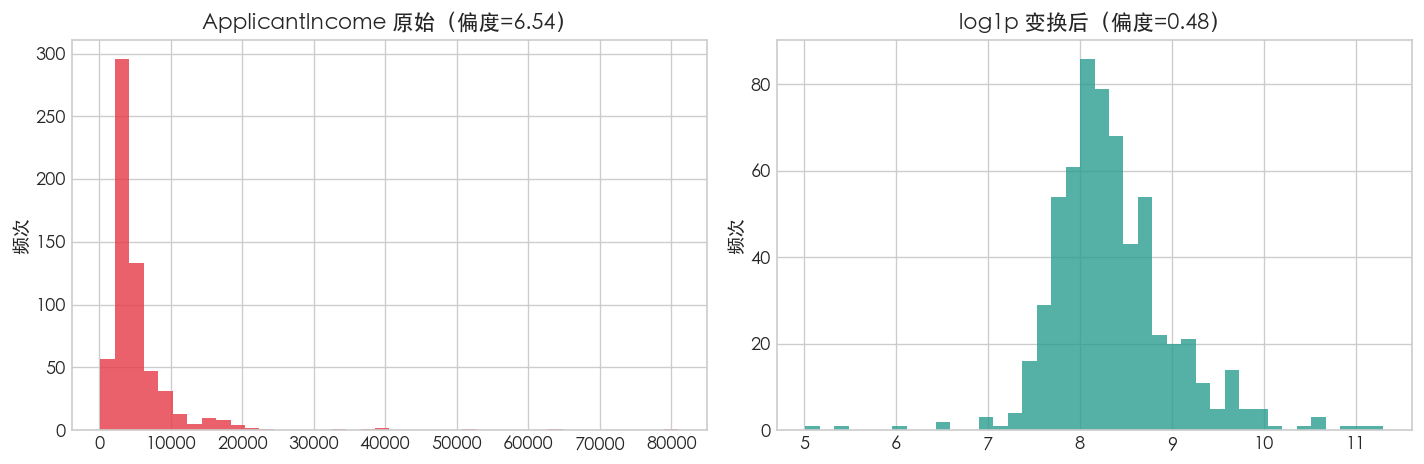

In [8]:
# log1p 变换后对比（ApplicantIncome 示例）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['ApplicantIncome'].dropna(), bins=40, color='#E63946', alpha=0.8)
axes[0].set_title(f'ApplicantIncome 原始（偏度={train["ApplicantIncome"].skew():.2f}）')
axes[1].hist(np.log1p(train['ApplicantIncome'].dropna()), bins=40, color='#2A9D8F', alpha=0.8)
axes[1].set_title(f'log1p 变换后（偏度={np.log1p(train["ApplicantIncome"]).skew():.2f}）')
for ax in axes:
    ax.set_ylabel('频次')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'log_transform_demo.png', dpi=150)
plt.show()

## 6. 类别特征与标签关联 <a id='6'></a>

分析各类别变量的贷款批准率，识别强预测因子。

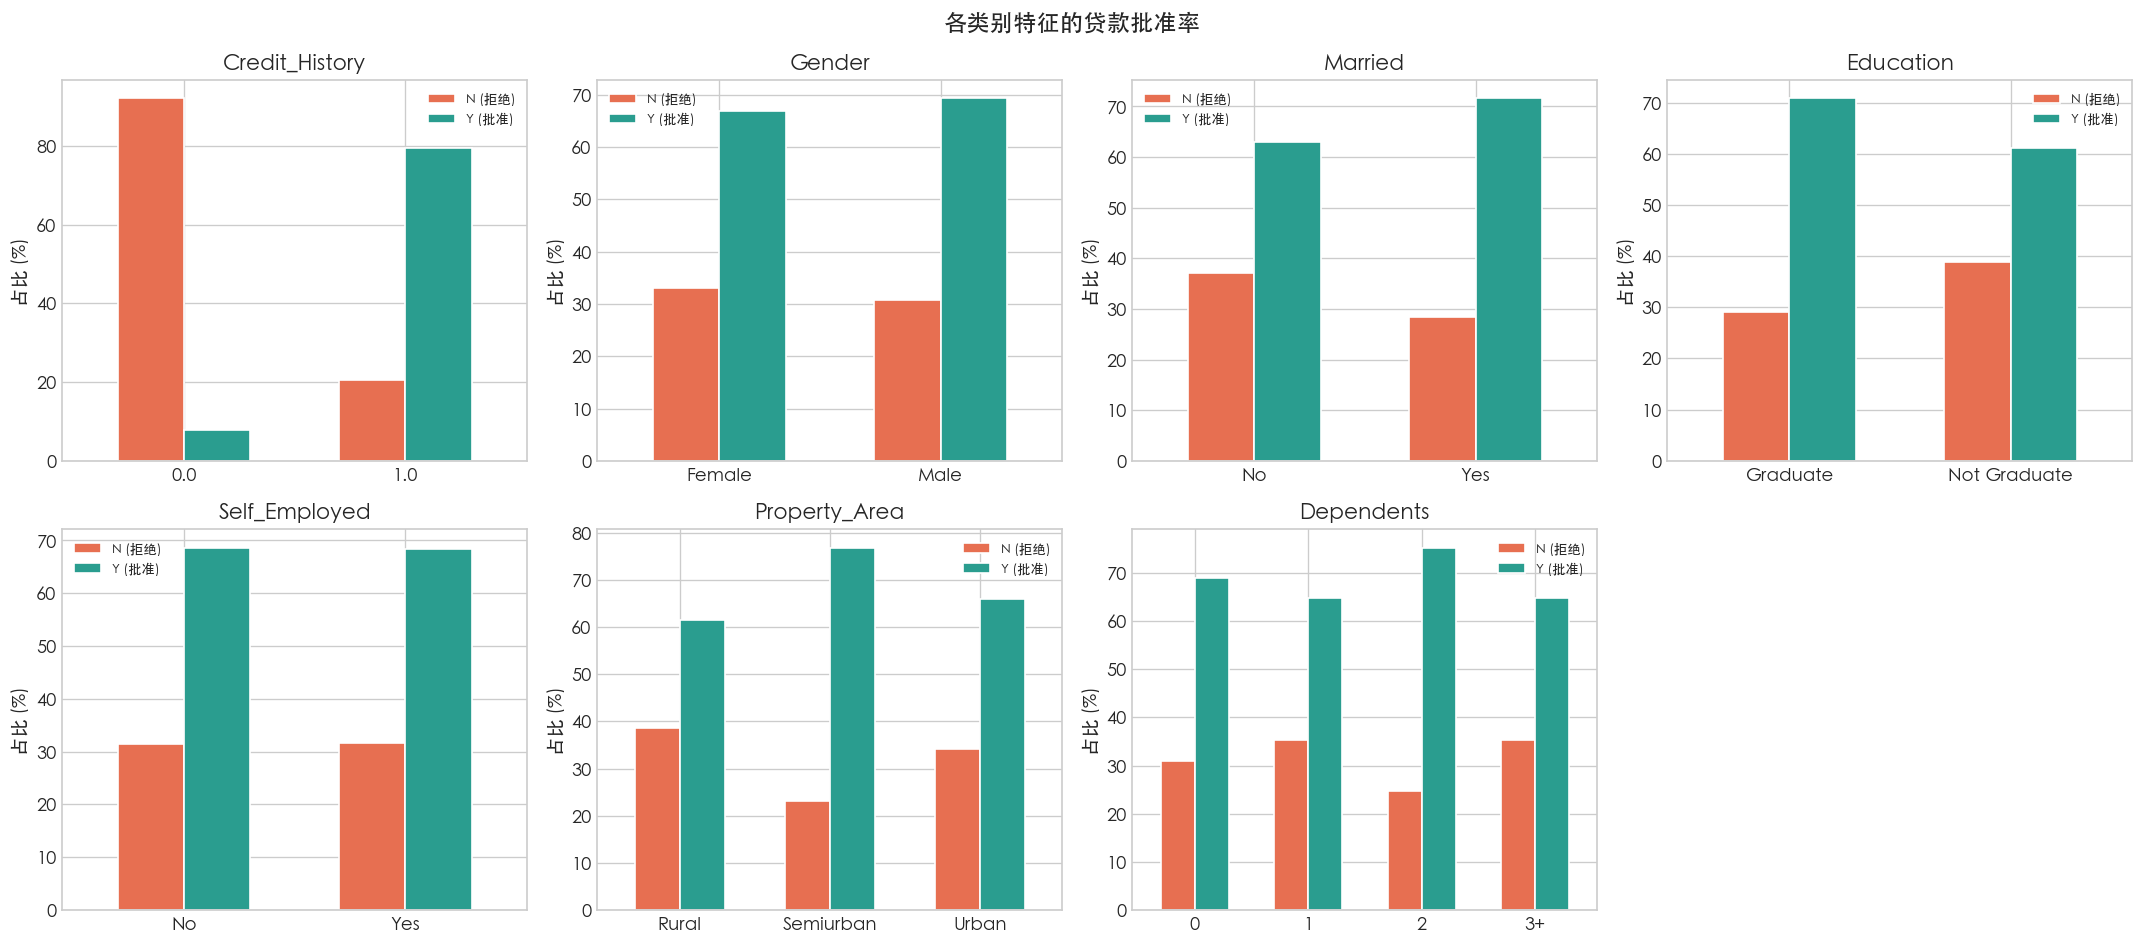

Credit_History vs Loan_Status：
Loan_Status         N      Y
Credit_History              
0.0             0.921  0.079
1.0             0.204  0.796


In [9]:
cat_cols = ['Credit_History', 'Gender', 'Married', 'Education',
            'Self_Employed', 'Property_Area', 'Dependents']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train[col], train['Loan_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#E76F51', '#2A9D8F'],
            edgecolor='white', width=0.6)
    axes[i].set_title(col)
    axes[i].set_ylabel('占比 (%)')
    axes[i].set_xlabel('')
    axes[i].legend(['N (拒绝)', 'Y (批准)'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

# 关掉多余子图
axes[-1].set_visible(False)

plt.suptitle('各类别特征的贷款批准率', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'categorical_vs_label.png', dpi=150)
plt.show()

# 打印 Credit_History（最强特征）的详细数据
print('Credit_History vs Loan_Status：')
print(pd.crosstab(train['Credit_History'], train['Loan_Status'],
                  normalize='index').round(3))

## 6.5 Credit_History 专项深度分析 <a id='6_5'></a>

Credit_History 是本数据集中**最强单特征**，以下从多维度量化其影响。

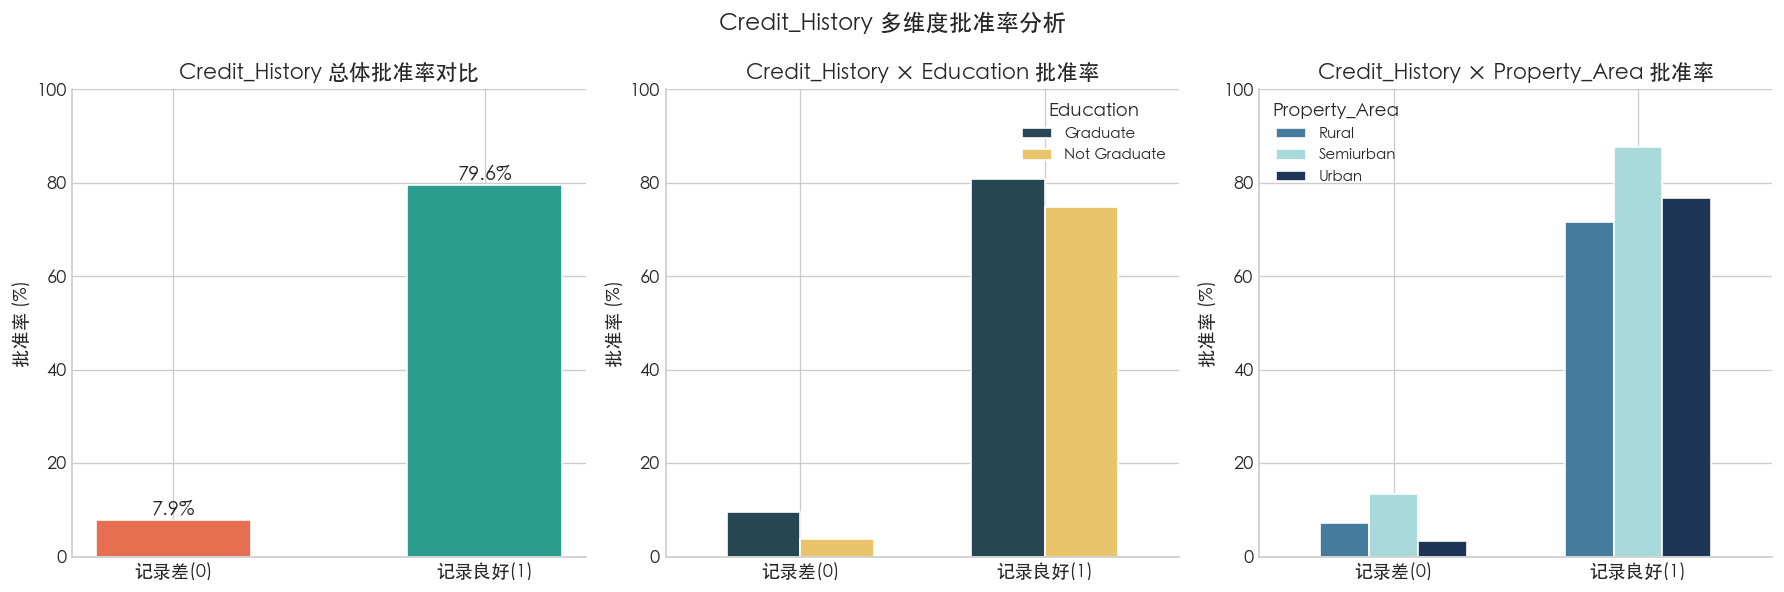

各群体批准率摘要：
Credit_History
记录差(0)     0.079
记录良好(1)    0.796
Name: Loan_Status, dtype: float64

Credit_History=1 覆盖样本: 475 / 614
Credit_History=0 覆盖样本: 89 / 614
Credit_History 缺失: 50 条（将按中位数=1填充）


In [10]:
# Credit_History 与各子群体的批准率交叉分析
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ① 总体通过率对比
ax = axes[0]
ch_rate = train.groupby('Credit_History')['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100
).reset_index()
ch_rate.columns = ['Credit_History', 'ApprovalRate']
bars = ax.bar(['记录差(0)', '记录良好(1)'], ch_rate['ApprovalRate'],
              color=['#E76F51', '#2A9D8F'], width=0.5, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('批准率 (%)')
ax.set_title('Credit_History 总体批准率对比', fontweight='bold')
ax.set_ylim(0, 100)
ax.spines[['top','right']].set_visible(False)

# ② Credit_History × Education 交叉
ax = axes[1]
ct = train.groupby(['Credit_History', 'Education'])['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100
).unstack()
ct.index = ['记录差(0)', '记录良好(1)']
ct.plot(kind='bar', ax=ax, color=['#264653', '#E9C46A'],
        edgecolor='white', width=0.6, rot=0)
ax.set_title('Credit_History × Education 批准率', fontweight='bold')
ax.set_ylabel('批准率 (%)')
ax.set_ylim(0, 100)
ax.legend(title='Education', fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ③ Credit_History × Property_Area 交叉
ax = axes[2]
ct2 = train.groupby(['Credit_History', 'Property_Area'])['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100
).unstack()
ct2.index = ['记录差(0)', '记录良好(1)']
ct2.plot(kind='bar', ax=ax, color=['#457B9D', '#A8DADC', '#1D3557'],
         edgecolor='white', width=0.6, rot=0)
ax.set_title('Credit_History × Property_Area 批准率', fontweight='bold')
ax.set_ylabel('批准率 (%)')
ax.set_ylim(0, 100)
ax.legend(title='Property_Area', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Credit_History 多维度批准率分析', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'credit_history_deep_analysis.png', dpi=150)
plt.show()

# 打印量化摘要
print('各群体批准率摘要：')
print(train.groupby('Credit_History')['Loan_Status']
      .apply(lambda x: (x=='Y').mean()).rename({0:'记录差(0)', 1:'记录良好(1)'}).round(3))
print(f'\nCredit_History=1 覆盖样本: {(train["Credit_History"]==1).sum()} / {len(train)}')
print(f'Credit_History=0 覆盖样本: {(train["Credit_History"]==0).sum()} / {len(train)}')
print(f'Credit_History 缺失: {train["Credit_History"].isna().sum()} 条（将按中位数=1填充）')

## 7. 业务派生特征预览 <a id='7'></a>

在 `features.py` 中构造的三个派生特征，此处预先验证其业务合理性。

In [11]:
df = train.copy()
df['TotalIncome']   = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI']           = df['LoanAmount'] / df['Loan_Amount_Term']
df['BalanceIncome'] = df['TotalIncome'] - df['EMI'] * 1000

print('派生特征统计摘要：')
print(df[['TotalIncome', 'EMI', 'BalanceIncome']].describe().round(2))
print(f"\nBalanceIncome 负值比例: {(df['BalanceIncome'] < 0).mean()*100:.1f}% （高风险信号）")

派生特征统计摘要：
       TotalIncome     EMI  BalanceIncome
count       614.00  578.00         578.00
mean       7024.71    0.48        6595.32
std        6458.66    0.53        6423.23
min        1442.00    0.02       -1768.00
25%        4166.00    0.29        3796.64
50%        5416.50    0.37        4970.33
75%        7521.75    0.51        6958.03
max       81000.00    9.25       80000.00

BalanceIncome 负值比例: 0.3% （高风险信号）


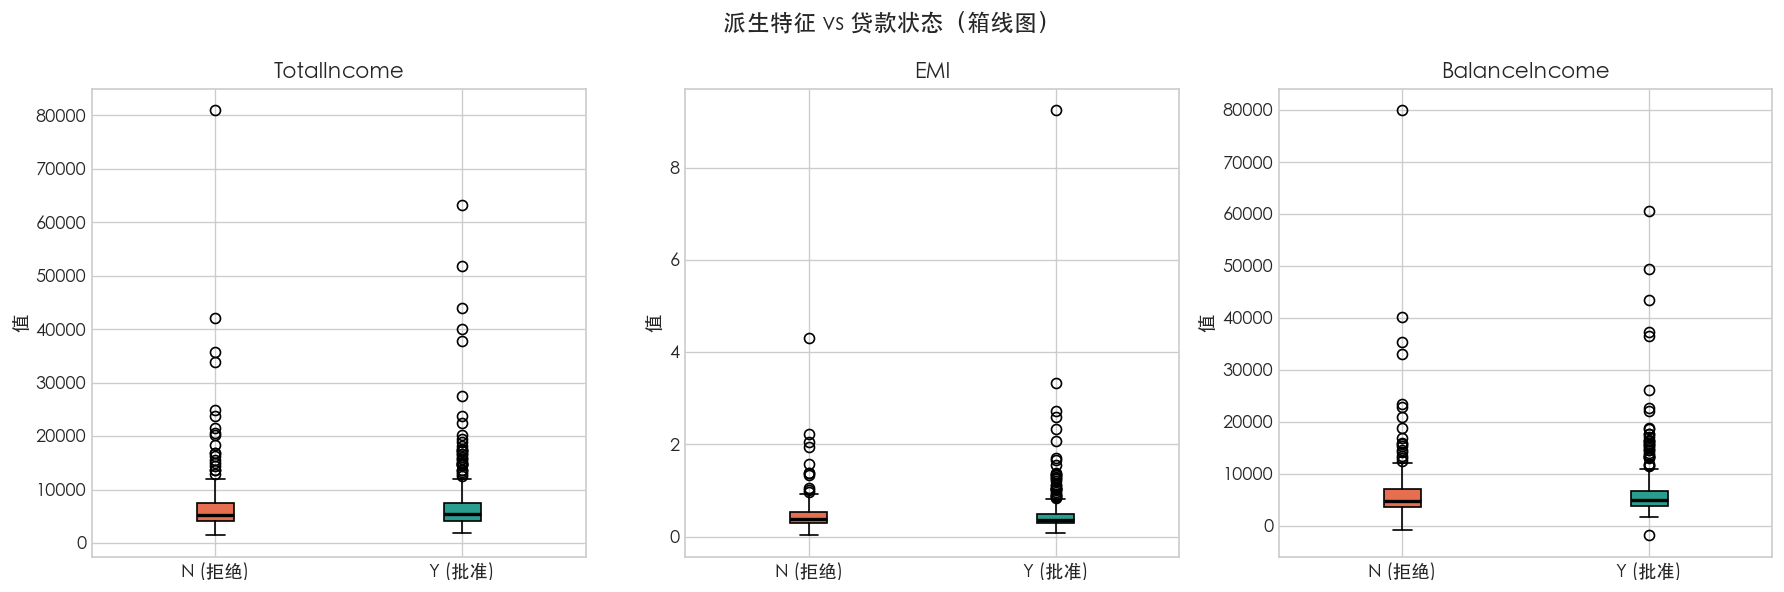

In [12]:
# 按 Loan_Status 分组箱线图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
derived_cols = ['TotalIncome', 'EMI', 'BalanceIncome']

for ax, col in zip(axes, derived_cols):
    groups = [df.loc[df['Loan_Status']=='N', col].dropna(),
              df.loc[df['Loan_Status']=='Y', col].dropna()]
    bp = ax.boxplot(groups, labels=['N (拒绝)', 'Y (批准)'],
                   patch_artist=True, notch=False,
                   medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#E76F51')
    bp['boxes'][1].set_facecolor('#2A9D8F')
    ax.set_title(col)
    ax.set_ylabel('值')

plt.suptitle('派生特征 vs 贷款状态（箱线图）', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'derived_features_boxplot.png', dpi=150)
plt.show()

## 8. 数值特征相关性热力图 <a id='8'></a>

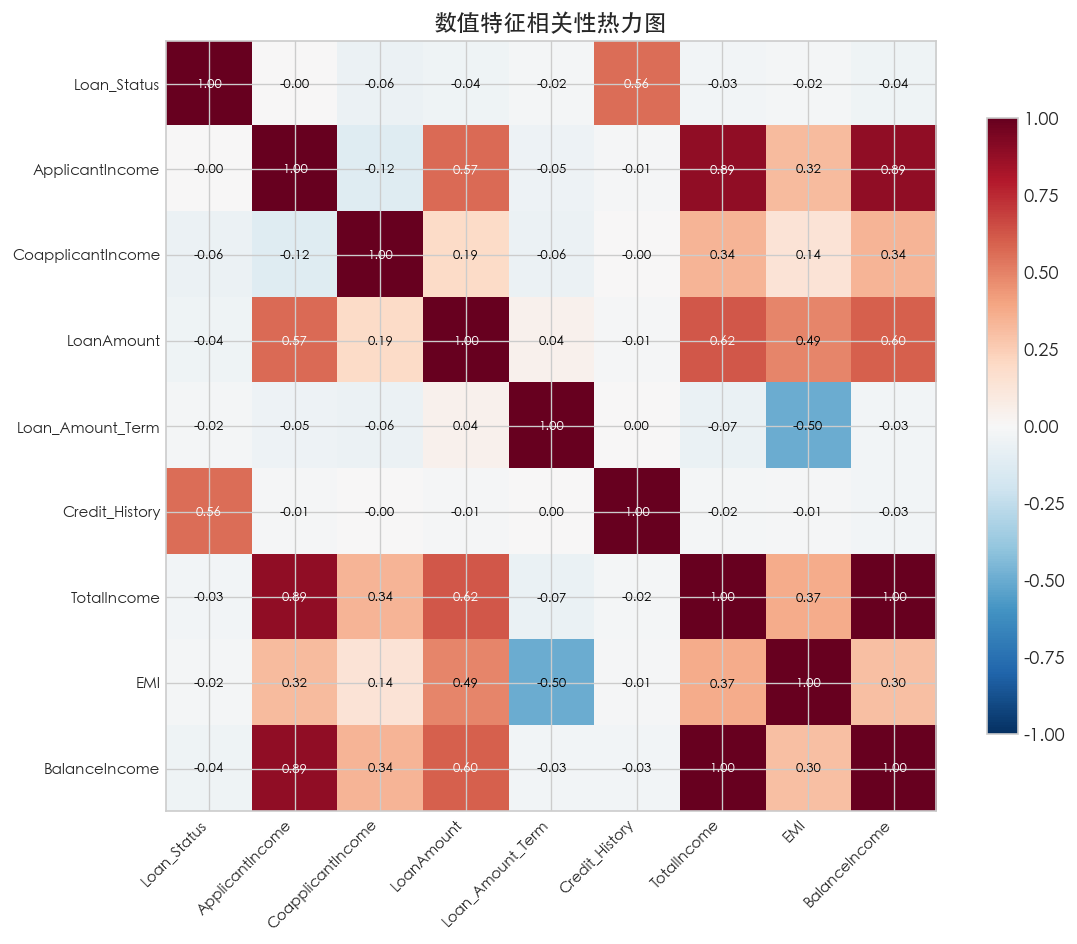

In [13]:
# 编码后计算相关性（仅数值列 + 标签）
enc = train.copy()
enc['Loan_Status'] = enc['Loan_Status'].map({'Y': 1, 'N': 0})
enc['Gender']    = enc['Gender'].map({'Male': 1, 'Female': 0})
enc['Married']   = enc['Married'].map({'Yes': 1, 'No': 0})
enc['Education'] = enc['Education'].map({'Graduate': 1, 'Not Graduate': 0})
enc['TotalIncome']   = enc['ApplicantIncome'] + enc['CoapplicantIncome']
enc['EMI']           = enc['LoanAmount'] / enc['Loan_Amount_Term']
enc['BalanceIncome'] = enc['TotalIncome'] - enc['EMI'] * 1000

num_feat = ['Loan_Status', 'ApplicantIncome', 'CoapplicantIncome',
            'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
            'TotalIncome', 'EMI', 'BalanceIncome']
corr = enc[num_feat].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(num_feat)))
ax.set_yticks(range(len(num_feat)))
ax.set_xticklabels(num_feat, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_feat, fontsize=9)
for i in range(len(num_feat)):
    for j in range(len(num_feat)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
ax.set_title('数值特征相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

## 8.5 类别不均衡处理策略可视化 <a id='8_5'></a>

对比 class_weight 与 SMOTE 两种策略在训练集上的标签分布效果。

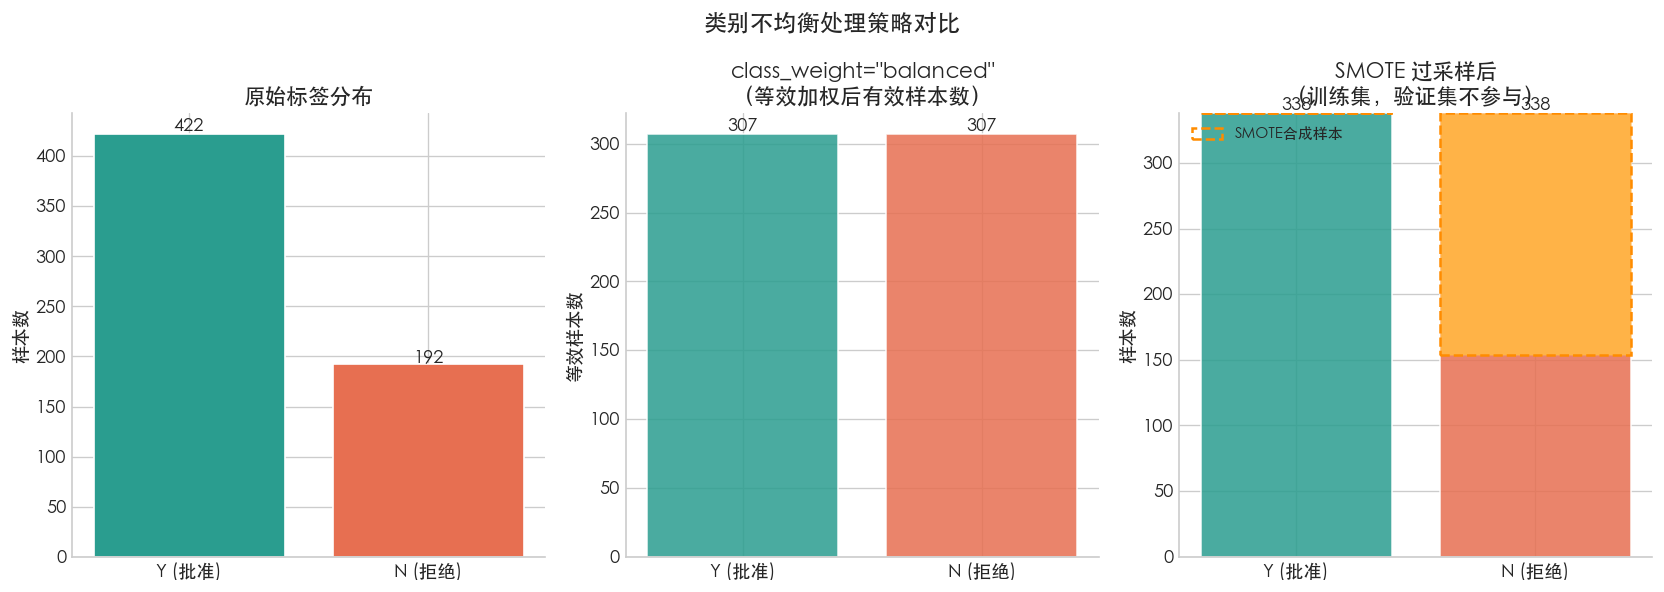

原始训练集（约80%）: Y≈338, N≈154, 比例=2.19:1
SMOTE后训练集:       Y≈338, N≈338, 比例=1:1（完全平衡）

class_weight 优势: 不改变数据量，计算开销低，小样本下更稳定
SMOTE 优势:         合成多样性样本，捕获少数类特征分布边界，特征空间更丰富


In [14]:
# 不均衡处理策略对比可视化
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labels_orig = train['Loan_Status'].value_counts()
colors_orig = ['#2A9D8F', '#E76F51']

# ① 原始分布
ax = axes[0]
ax.bar(['Y (批准)', 'N (拒绝)'], [labels_orig.get('Y', 0), labels_orig.get('N', 0)],
       color=colors_orig, edgecolor='white')
ax.set_title('原始标签分布', fontweight='bold')
ax.set_ylabel('样本数')
for i, v in enumerate([labels_orig.get('Y', 0), labels_orig.get('N', 0)]):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# ② class_weight='balanced'（等效权重分布）
ax = axes[1]
n_total = len(train)
n_y, n_n = labels_orig.get('Y', 0), labels_orig.get('N', 0)
w_y = n_total / (2 * n_y)   # balanced 公式：n_samples / (n_classes * n_samples_class)
w_n = n_total / (2 * n_n)
ax.bar(['Y (批准)', 'N (拒绝)'], [n_y * w_y, n_n * w_n],
       color=colors_orig, edgecolor='white', alpha=0.85)
ax.set_title('class_weight="balanced"\n（等效加权后有效样本数）', fontweight='bold')
ax.set_ylabel('等效样本数')
for i, v in enumerate([n_y * w_y, n_n * w_n]):
    ax.text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# ③ SMOTE 过采样后（少数类补至与多数类相同）
ax = axes[2]
# 训练集（80%）中的分布估算
n_y_train = round(n_y * 0.8)
n_n_train = round(n_n * 0.8)
ax.bar(['Y (批准)', 'N (拒绝)'], [n_y_train, n_y_train],  # SMOTE 将N补至与Y相同
       color=colors_orig, edgecolor='white', alpha=0.85)
ax.bar(['Y (批准)', 'N (拒绝)'], [0, n_y_train - n_n_train],
       bottom=[n_y_train, n_n_train],
       color=['none', '#FFB347'], edgecolor='#FF8C00',
       linestyle='--', linewidth=1.5, label='SMOTE合成样本')
ax.set_title('SMOTE 过采样后\n（训练集，验证集不参与）', fontweight='bold')
ax.set_ylabel('样本数')
ax.legend(fontsize=9)
for i, v in enumerate([n_y_train, n_y_train]):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('类别不均衡处理策略对比', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_FIG_DIR / 'imbalance_strategy_compare.png', dpi=150)
plt.show()

print(f'原始训练集（约80%）: Y≈{n_y_train}, N≈{n_n_train}, 比例={n_y_train/n_n_train:.2f}:1')
print(f'SMOTE后训练集:       Y≈{n_y_train}, N≈{n_y_train}, 比例=1:1（完全平衡）')
print(f'\nclass_weight 优势: 不改变数据量，计算开销低，小样本下更稳定')
print(f'SMOTE 优势:         合成多样性样本，捕获少数类特征分布边界，特征空间更丰富')

## 9. EDA 结论与数据处理建议 <a id='9'></a>

### 数据质量问题

| 问题 | 详情 | 处理方案 |
|------|------|----------|
| 缺失值 | Credit_History 缺失最多（8.1%），共 7 列有缺失 | 分类→众数，数值→中位数 |
| 类别不均衡 | Y:N ≈ 2.2:1 | class_weight='balanced' / scale_pos_weight |
| 高偏度 | ApplicantIncome 偏度 6.5，CoapplicantIncome 7.5 | log1p 变换 |

### 关键发现

1. **Credit_History 是最强预测因子**：信用记录良好（=1）的申请人批准率 **79.6%**，
   信用记录差（=0）的批准率仅 **7.9%**，差距极显著。

2. **婚姻状况有一定影响**：已婚申请人批准率（71.6%）高于未婚（62.9%），
   可能与双收入有关（TotalIncome 更高）。

3. **Property_Area 有差异**：Semiurban 区域批准率最高（76.8%），
   Rural 最低（61.5%）。

4. **Education 影响适中**：本科及以上批准率（70.8%）略高于非本科（61.2%）。

5. **BalanceIncome 分布验证派生特征的有效性**：
   批准组（Y）的 TotalIncome 和 BalanceIncome 中位数显著高于拒绝组（N），
   说明收入偿债能力特征对标签有较强区分力。

### 特征工程决策依据

- `TotalIncome`：比单独的 ApplicantIncome 更全面反映家庭还款能力
- `EMI`：直接量化月还款压力，是信贷风控核心指标
- `BalanceIncome`：负值（入不敷出）是违约高风险信号，特征重要性排名第 3
